In [ ]:
from google.colab import files
files.upload() # Upload your kaggle.json here

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nipundewangan123","key":"83b6e376453b41e5ff088031f8ffc530"}'}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import kagglehub

# Download the dataset and define 'path'
# This ensures 'path' is defined before its first use in this cell.
path = kagglehub.dataset_download("prithwirajmitra/covid-face-mask-detection-dataset")
print("Dataset location:", path)

# List the top-level folders
print("Main Directory:", path)
!ls '{path}'

# Drill down into the actual image folders
# Based on the dataset name, it likely has 'with_mask' and 'without_mask' folders
print("\nClasses found:")
# Corrected to reflect the actual path within the dataset, as inferred from other cells
!ls '{path}/New Masks Dataset/Train'


100%|██████████| 207M/207M [00:01<00:00, 149MB/s]

Extracting files...


Dataset location: /root/.cache/kagglehub/datasets/prithwirajmitra/covid-face-mask-detection-dataset/versions/1
Main Directory: /root/.cache/kagglehub/datasets/prithwirajmitra/covid-face-mask-detection-dataset/versions/1
'New Masks Dataset'

Classes found:
 Mask  'Non Mask'


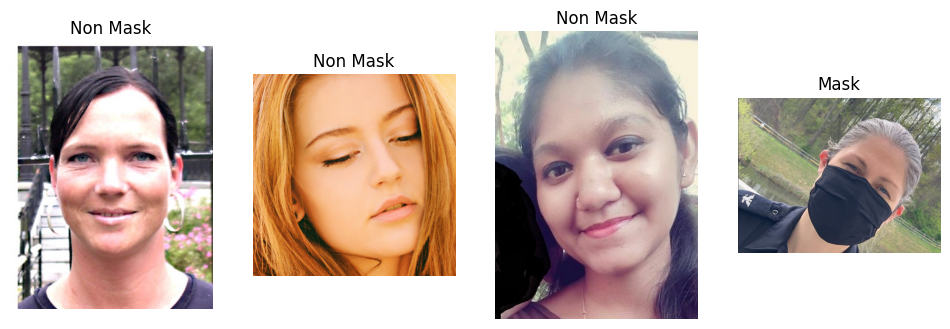

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random

# Get a list of all image paths
all_images = []
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):
            all_images.append(os.path.join(root, file))

# Pick 4 random images to show
plt.figure(figsize=(12, 8))
for i in range(4):
    img_path = random.choice(all_images)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB

    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.title(img_path.split('/')[-2]) # Shows the folder name (the label)
    plt.axis('off')
plt.show()

In [ ]:
!ln -s '{path}' /content/dataset_shortcut

In [ ]:
import kagglehub

# This downloads the dataset directly into the Colab environment
path = kagglehub.dataset_download("prithwirajmitra/covid-face-mask-detection-dataset")
print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/prithwirajmitra/covid-face-mask-detection-dataset/versions/1


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
import kagglehub
import os

# Download
path = kagglehub.dataset_download("prithwirajmitra/covid-face-mask-detection-dataset")

# See what's inside
print("Dataset location:", path)
print("Folders found:", os.listdir(path))

Dataset location: /root/.cache/kagglehub/datasets/prithwirajmitra/covid-face-mask-detection-dataset/versions/1
Folders found: ['New Masks Dataset']


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import pandas as pd
import tensorflow as tf
from keras.preprocessing import image

In [ ]:
import kagglehub

# Ensure 'path' is correctly set to the dataset root
path = kagglehub.dataset_download("prithwirajmitra/covid-face-mask-detection-dataset")

dataset_root = path # 'path' from previous cell holds the base dataset directory
categories = ['Mask', 'Non Mask'] # Updated to match actual folder names
data=[]
for category in categories:
    current_path = os.path.join(dataset_root, 'New Masks Dataset', 'Train', category)
    label=categories.index(category)
    for file in os.listdir(current_path):
        img_path = os.path.join(current_path, file)
        img = cv2.imread(img_path)
        img=cv2.resize(img,(224,224))

        data.append([img,label])


In [ ]:
len(data)

600

In [ ]:
import random
random.shuffle(data)

In [ ]:
x=[]
y=[]
for features,label in data:
  x.append(features)
  y.append(label)


In [ ]:
len(x)

600

In [ ]:
len(y)

600

In [ ]:
X=np.array(x)
y=np.array(y)

In [ ]:
X.shape

(600, 224, 224, 3)

In [ ]:
y.shape

(600,)

In [ ]:
X=X/255


In [ ]:
X[0]

array([[[0.01568627, 0.03529412, 0.03137255],
        [0.01568627, 0.03529412, 0.03137255],
        [0.02352941, 0.04313725, 0.03921569],
        ...,
        [0.03137255, 0.00392157, 0.00392157],
        [0.03137255, 0.00392157, 0.00392157],
        [0.03137255, 0.00392157, 0.00392157]],

       [[0.84313725, 0.85882353, 0.8627451 ],
        [0.84313725, 0.8627451 , 0.8627451 ],
        [0.85490196, 0.87058824, 0.87058824],
        ...,
        [0.89803922, 0.89803922, 0.89411765],
        [0.89019608, 0.89411765, 0.88627451],
        [0.89019608, 0.89019608, 0.88235294]],

       [[0.84313725, 0.8627451 , 0.86666667],
        [0.84705882, 0.8627451 , 0.87058824],
        [0.84705882, 0.86666667, 0.87058824],
        ...,
        [0.85098039, 0.87843137, 0.8745098 ],
        [0.84705882, 0.87843137, 0.8745098 ],
        [0.85098039, 0.87843137, 0.8745098 ]],

       ...,

       [[0.47843137, 0.63921569, 0.81568627],
        [0.48627451, 0.64705882, 0.82352941],
        [0.49019608, 0

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [ ]:
X_train.shape

(480, 224, 224, 3)

In [ ]:
y_test.shape

(120,)

In [ ]:
from keras.applications.vgg16 import VGG16
vgg=VGG16()


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
vgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras import Sequential
model=Sequential()
for layer in vgg.layers[:-1]:
  model.add(layer)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
for layer in model.layers:
  layer.trainable=False


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 134,260,544 (512.16 MB)

In [ ]:
from keras.layers import Dense
model.add(Dense(1,activation='sigmoid'))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,264,641 (512.18 MB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 134,260,544 (512.16 MB)

In [ ]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])
model.fit(X_train,y_train,epochs=5,validation_data=(X_test,y_test))

Epoch 1/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.6062 - loss: 0.6753 - val_accuracy: 0.8083 - val_loss: 0.5319
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 211ms/step - accuracy: 0.7833 - loss: 0.4904 - val_accuracy: 0.8083 - val_loss: 0.4554
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 216ms/step - accuracy: 0.8729 - loss: 0.4015 - val_accuracy: 0.8583 - val_loss: 0.3780
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 213ms/step - accuracy: 0.9062 - loss: 0.3433 - val_accuracy: 0.8833 - val_loss: 0.3386
Epoch 5/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 211ms/step - accuracy: 0.9104 - loss: 0.2960 - val_accuracy: 0.8833 - val_loss: 0.3026


In [ ]:
def detectfacemask(img):
  # Changed 223 to 224 to match the resized image shape
  y_pred = model.predict(img.reshape(1, 224, 224, 3))
  return y_pred

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Confidence: 0.5689596
Prediction: No Mask


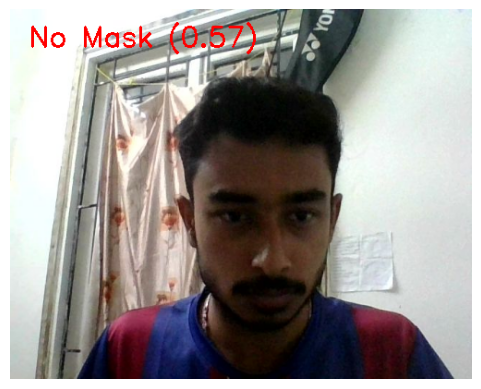

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np

def take_photo(filename='photo.jpg', quality=0.8):

    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getVideoTracks()[0].stop();
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')

    display(js)
    data = eval_js('takePhoto({})'.format(quality))

    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename
try:
    filename = take_photo()
    result = detect_and_label(filename)
    print("Prediction:", result)
except Exception as err:
    print("Error:", err)

Saving Old Photo.jpg to Old Photo.jpg
Processing Old Photo.jpg...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Confidence: 0.88309455


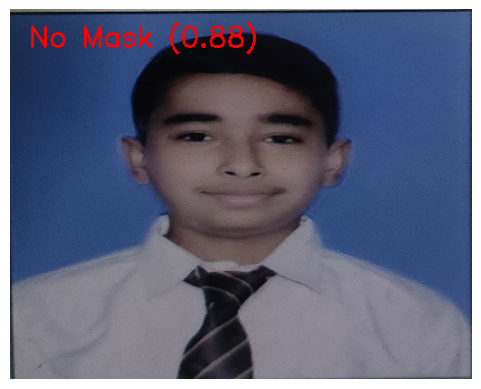

In [ ]:
from google.colab import files

def upload_and_predict():
    uploaded = files.upload()

    for name, data in uploaded.items():
        with open(name, 'wb') as f:
            f.write(data)

        print(f'Processing {name}...')
        detect_and_label(name)

# Call this to open the upload dialog
upload_and_predict()

In [ ]:
!pip install opencv-python

In [93]:
import cv2
import numpy as np
from base64 import b64decode
from IPython.display import display, Javascript, clear_output
from google.colab.output import eval_js
import matplotlib.pyplot as plt
from keras.applications.vgg16 import preprocess_input
import time

# Load your mask detection model here
# model = tf.keras.models.load_model('mask_detector.h5')

face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)
print("Model and detector ready.")

Model and detector ready.


In [100]:
display(Javascript('''
// Reset state on re-run
window.cameraReady = false;
window.video      = null;
window.canvas     = null;
window.ctx        = null;

// ✅ Attached to window so eval_js can find it
window.capture = function() {
  if (!window.cameraReady || !window.video) return null;
  window.canvas.width  = window.video.videoWidth;
  window.canvas.height = window.video.videoHeight;
  window.ctx.drawImage(window.video, 0, 0);
  return window.canvas.toDataURL('image/jpeg', 0.8);
};

(async function init_camera() {
  try {
    const stream = await navigator.mediaDevices.getUserMedia({ video: true });

    window.video = document.createElement('video');
    window.video.srcObject = stream;
    window.video.setAttribute('playsinline', true);  // needed on mobile
    await window.video.play();

    window.canvas = document.createElement('canvas');
    window.ctx    = window.canvas.getContext('2d');

    window.cameraReady = true;
    console.log("✅ Camera ready");
  } catch (e) {
    console.error("❌ Camera failed:", e);
  }
})();
'''))

<IPython.core.display.Javascript object>

In [101]:
# ✅ Poll instead of blind time.sleep — reliable across all machines
print("Waiting for camera... Please click 'Allow' if prompted by your browser.")
for i in range(40):                              # up to 20 seconds
    try:
        if eval_js('window.cameraReady === true'):
            print("Camera ready!")
            break
    except Exception:
        # JavaScript might not be initialized yet
        pass
    time.sleep(0.5)
else:
    print("\n--- TROUBLESHOOTING ---")
    print("1. Ensure you ran the cell with id 'zK1sS9jVCCCG' right before this.")
    print("2. Look for a camera icon in your browser's address bar and enable permissions.")
    print("3. Try refreshing the page if the camera light is on but it still times out.")
    raise RuntimeError("Camera timed out. Check browser permissions.")

Waiting for camera... Please click 'Allow' if prompted by your browser.

--- TROUBLESHOOTING ---
1. Ensure you ran the cell with id 'zK1sS9jVCCCG' right before this.
2. Look for a camera icon in your browser's address bar and enable permissions.
3. Try refreshing the page if the camera light is on but it still times out.


RuntimeError: Camera timed out. Check browser permissions.

In [ ]:
def process_frame(data_url):
    if not data_url:
        return None

    # Decode base64 → numpy frame
    binary = b64decode(data_url.split(',')[1])
    arr    = np.frombuffer(binary, dtype=np.uint8)
    frame  = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    if frame is None:
        return None

    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_detector.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    for (x, y, w, h) in faces:
        # Crop + preprocess face ROI
        roi        = frame[y:y+h, x:x+w]
        roi_input  = cv2.resize(roi, (224, 224)).astype(np.float32)
        roi_input  = preprocess_input(roi_input).reshape(1, 224, 224, 3)

        pred       = model.predict(roi_input, verbose=0)[0][0]
        label      = "Mask"    if pred < 0.5 else "No Mask"
        color      = (0,255,0) if pred < 0.5 else (0,0,255)
        confidence = (1 - pred) if pred < 0.5 else pred

        cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)
        cv2.putText(
            frame, f"{label} {confidence:.0%}",
            (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2
        )

    return frame

In [ ]:
print("Streaming — hit ■ Stop to quit.")
try:
    while True:
        data_url = eval_js('window.capture()')   # ✅ window. prefix = always found

        if not data_url:
            time.sleep(0.3)
            continue

        frame = process_frame(data_url)
        if frame is not None:
            plt.figure(figsize=(8, 6))
            plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.tight_layout()
            display(plt.gcf())
            clear_output(wait=True)
            plt.close()

        time.sleep(0.1)   # ~10 fps

except KeyboardInterrupt:
    print("Stream stopped.")
except Exception as e:
    print(f"Error: {e}")
    raise

In [ ]:
from google.colab.output import eval_js
from IPython.display import display, Javascript

display(Javascript('''
// Report exactly what's blocking the camera
(async function diagnose() {
  const report = {};

  // Check 1: Is getUserMedia even available?
  report.apiAvailable = !!(navigator.mediaDevices && navigator.mediaDevices.getUserMedia);

  // Check 2: Current permission state
  try {
    const perm = await navigator.permissions.query({ name: 'camera' });
    report.permissionState = perm.state; // 'granted', 'denied', or 'prompt'
  } catch(e) {
    report.permissionState = 'query-not-supported';
  }

  // Check 3: Is page served over HTTPS? (required for camera)
  report.isHttps = location.protocol === 'https:';

  // Check 4: Try to actually open the camera
  try {
    const stream = await navigator.mediaDevices.getUserMedia({ video: true });
    stream.getTracks().forEach(t => t.stop()); // release immediately
    report.cameraOpened = true;
  } catch(e) {
    report.cameraOpened = false;
    report.cameraError  = e.name + ': ' + e.message;
  }

  window._diagResult = JSON.stringify(report, null, 2);
  console.log("Diagnosis:", window._diagResult);
})();
'''))

import time
time.sleep(3)

result = eval_js('window._diagResult || "Diagnosis did not complete"')
print("=== Camera Diagnosis ===")
print(result)

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import time

# ✅ Single cell — no context loss between cells
display(Javascript('''
window.cameraReady = false;
window._cameraError = null;

window.capture = function() {
  if (!window.cameraReady || !window.video) return null;
  window.canvas.width  = window.video.videoWidth;
  window.canvas.height = window.video.videoHeight;
  window.ctx.drawImage(window.video, 0, 0);
  return window.canvas.toDataURL('image/jpeg', 0.8);
};

(async function() {
  try {
    const stream = await navigator.mediaDevices.getUserMedia({ video: true });
    window.video = document.createElement('video');
    window.video.srcObject = stream;
    window.video.setAttribute('playsinline', true);
    await window.video.play();
    window.canvas = document.createElement('canvas');
    window.ctx    = window.canvas.getContext('2d');
    window.cameraReady = true;
  } catch(e) {
    window._cameraError = e.name + ': ' + e.message;
  }
})();
'''))

# Poll for result
print("Waiting for camera...")
for _ in range(40):
    time.sleep(0.5)
    ready = eval_js('window.cameraReady')
    error = eval_js('window._cameraError')
    if error:
        print(f"\n❌ Camera error: {error}")
        print("\nFix: Close Zoom/Teams/Discord, check browser permissions, then re-run.")
        break
    if ready:
        print("✅ Camera ready!")
        break
else:
    print("❌ Timed out — browser may be waiting for your permission click.")